# 01 — Análise exploratória

Este notebook estabelece **o que é possível prever** com o extrato da Locaweb antes de qualquer
modelo. Três perguntas, nesta ordem:

1. Qual é a janela de dados realmente utilizável?
2. Qual série deve ser o alvo — o volume bruto ou o volume elegível a KPI?
3. Quanto sinal existe no alvo de violação de OLA?

As respostas daqui definem decisões que atravessam todo o resto do pipeline.

In [1]:
import sys, warnings
from pathlib import Path

warnings.filterwarnings('ignore')
RAIZ = Path.cwd().parents[1] if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(RAIZ))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 40)
plt.rcParams['figure.figsize'] = (11, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25

from ml.src import config, dataset, explain, features, metrics, models_zoo, registry, selecao, splits, train
print('Banco:', config.BANCO, '| existe:', config.BANCO.exists())

Banco: C:\Users\Usuario\Downloads\CP\sentinel_ops\db.sqlite3 | existe: True


In [2]:
incidentes = dataset.carregar_incidentes()
resumo = dataset.resumo(incidentes)
for chave, valor in resumo.items():
    print(f'{chave:>20}: {valor}')

          incidentes: 122543
       elegiveis_kpi: 25600
           violacoes: 248
            produtos: 51
             equipes: 17
  itens_configuracao: 9171
            familias: 12
              inicio: 2023-01-02 00:00:00
                 fim: 2025-12-31 00:00:00


## 1. A janela utilizável

O extrato cobre três anos, mas a densidade não é uniforme. A tabela mensal abaixo mostra o
problema: 2023 e 2024 somam menos incidentes elegíveis do que **um mês** de 2025.

In [3]:
diario = incidentes.groupby('data').agg(
    total=('numero', 'size'),
    kpi=('entrou_kpi', 'sum'),
)
diario['violacoes'] = (
    incidentes.assign(v=incidentes['kpi_violado'].fillna(False).astype(bool).astype(int))
    .groupby('data')['v'].sum()
)
mensal = diario.resample('MS').sum()
mensal.tail(18)

,total,kpi,violacoes
data,,,
2024-07-01,44,30,0
2024-08-01,39,23,0
2024-09-01,34,22,0
2024-10-01,50,35,0
2024-11-01,75,46,0
2024-12-01,271,118,3
2025-01-01,3714,2357,23
2025-02-01,3553,2282,25
2025-03-01,3588,2130,19


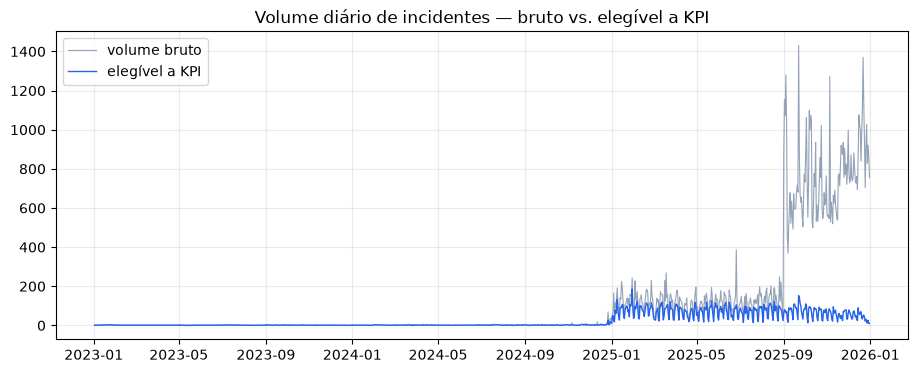

In [4]:
fig, eixo = plt.subplots()
eixo.plot(diario.index, diario['total'], lw=0.8, label='volume bruto', color='#94a3b8')
eixo.plot(diario.index, diario['kpi'], lw=1.0, label='elegível a KPI', color='#2563eb')
eixo.set_title('Volume diário de incidentes — bruto vs. elegível a KPI')
eixo.legend()
plt.show()

### A ruptura de setembro/2025 está no ruído, não no sinal

O volume bruto salta de ~130/dia para ~780/dia em 01/09/2025 e nunca mais volta. O volume
**elegível a KPI** não acompanha: segue na mesma faixa de sempre.

A leitura: entrou em operação uma nova cobertura de monitoramento automático, que abre chamado
sozinha e fecha sozinha. Isso não é carga operacional nem é medido por OLA.

**Decisão que sai daqui:** o alvo dos modelos de volume é `total_kpi`, não `total`. Prever o
volume bruto seria prever o comportamento de um robô.

In [5]:
corte = pd.Timestamp('2025-09-01')
antes = diario.loc['2025-01-01':corte - pd.Timedelta(days=1)]
depois = diario.loc[corte:]
comparacao = pd.DataFrame({
    'antes de 01/09': [antes['total'].mean(), antes['kpi'].mean()],
    'a partir de 01/09': [depois['total'].mean(), depois['kpi'].mean()],
}, index=['volume bruto/dia', 'elegível a KPI/dia']).round(1)
comparacao['variação %'] = (
    (comparacao['a partir de 01/09'] / comparacao['antes de 01/09'] - 1) * 100
).round(1)
comparacao

,antes de 01/09,a partir de 01/09,variação %
volume bruto/dia,116.8,765.8,555.7
elegível a KPI/dia,72.6,61.5,-15.3


### Detecção do início do regime

O corte não é escolhido a dedo: `splits.detectar_inicio_regime` procura o primeiro dia a partir
do qual a mediana móvel de 28 dias nunca mais cai abaixo de 25% da mediana do período final.

In [6]:
serie_kpi = diario['kpi'].reindex(
    pd.date_range(diario.index.min(), diario.index.max()), fill_value=0,
)
inicio = splits.detectar_inicio_regime(serie_kpi)
print('Início do regime operacional detectado:', inicio.date())
print('Dias utilizáveis:', (serie_kpi.index.max() - inicio).days + 1)
print('Incidentes descartados (backfill):', int((incidentes['data'] < inicio).sum()))

Início do regime operacional detectado: 2025-01-13
Dias utilizáveis: 353
Incidentes descartados (backfill): 1873


## 2. Sazonalidade do alvo

O perfil semanal é forte e estável — é a estrutura que qualquer modelo precisa capturar, e é
também a razão de a baseline de comparação ser a sazonal ingênua (repetir o mesmo dia da semana
anterior) e não a média simples.

In [7]:
regime = diario.loc[inicio:]
perfil = regime.groupby(regime.index.dayofweek)['kpi'].agg(['mean', 'std', 'count'])
perfil.index = ['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sáb', 'Dom']
perfil['índice'] = (perfil['mean'] / regime['kpi'].mean()).round(2)
perfil.round(1)

,mean,std,count,índice
Seg,80.4,21.9,51,1.2
Ter,87.6,22.3,51,1.3
Qua,85.1,21.0,51,1.2
Qui,86.0,26.2,50,1.2
Sex,77.3,17.0,50,1.1
Sáb,42.1,12.4,50,0.6
Dom,26.7,8.9,50,0.4


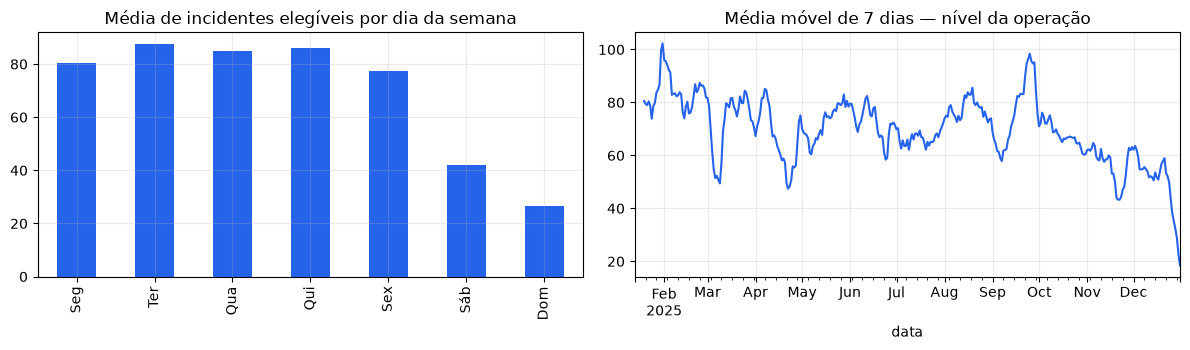

In [8]:
fig, (a, b) = plt.subplots(1, 2, figsize=(12, 3.6))
perfil['mean'].plot(kind='bar', ax=a, color='#2563eb')
a.set_title('Média de incidentes elegíveis por dia da semana')
regime['kpi'].rolling(7).mean().plot(ax=b, color='#2563eb')
b.set_title('Média móvel de 7 dias — nível da operação')
plt.tight_layout(); plt.show()

## 3. Quanto sinal existe para prever violação de OLA

Esta é a limitação mais séria do dataset, e precisa ficar explícita antes de qualquer modelo:
**violação de OLA é um evento raro**.

In [9]:
elegiveis = incidentes[incidentes['entrou_kpi'] & incidentes['kpi_violado'].notna()].copy()
elegiveis = elegiveis[elegiveis['data'] >= inicio]
elegiveis['violou'] = elegiveis['kpi_violado'].astype(bool).astype(int)

print(f'Incidentes elegíveis no regime : {len(elegiveis):,}')
print(f'Violações                      : {elegiveis["violou"].sum():,}')
print(f'Taxa de violação               : {elegiveis["violou"].mean() * 100:.2f}%')
print(f'Dias com ao menos uma violação : {(regime["violacoes"] > 0).sum()} de {len(regime)}')

Incidentes elegíveis no regime : 24,514
Violações                      : 231
Taxa de violação               : 0.94%
Dias com ao menos uma violação : 159 de 353


In [10]:
por_prioridade = elegiveis.groupby('prioridade')['violou'].agg(['size', 'sum', 'mean'])
por_prioridade.columns = ['incidentes', 'violações', 'taxa']
print('Só P2 e P3 entram no KPI:')
display(por_prioridade.round(4))

por_equipe = elegiveis.groupby('equipe')['violou'].agg(['size', 'sum', 'mean'])
por_equipe.columns = ['incidentes', 'violações', 'taxa']
por_equipe = por_equipe[por_equipe['incidentes'] >= 200].sort_values('taxa', ascending=False)
print('\nTaxa por equipe (≥200 incidentes) — a variação é o que dá sinal ao modelo:')
display(por_equipe.round(4))

Só P2 e P3 entram no KPI:


,incidentes,violações,taxa
prioridade,,,
2,4990,40,0.0080
3,19524,191,0.0098



Taxa por equipe (≥200 incidentes) — a variação é o que dá sinal ao modelo:


,incidentes,violações,taxa
equipe,,,
Team03,400,12,0.0300
Team09,1918,52,0.0271
Team11,8456,111,0.0131
Team12,381,5,0.0131
Team02,239,3,0.0126
Team17,470,4,0.0085
Team05,3264,12,0.0037
Team14,8745,10,0.0011


In [11]:
por_origem = elegiveis.groupby('aberto_por')['violou'].agg(['size', 'mean']).round(4)
por_origem.columns = ['incidentes', 'taxa de violação']
por_origem

,incidentes,taxa de violação
aberto_por,,
manual,15277,0.0124
monitoramento,9237,0.0044


**Conclusões que viram decisão de modelagem:**

- Taxa de violação de ~1% ⇒ classe severamente desbalanceada. A métrica principal do modelo de
  OLA será **PR-AUC**, não acurácia, e o limiar de decisão precisa ser escolhido na validação —
  no corte natural de 0,5 o modelo nunca dispararia.
- A taxa varia mais de 20× entre equipes e quase 3× entre chamados manuais e automáticos. Existe
  sinal a aprender; não é ruído puro.
- A probabilidade prevista precisará ser **calibrada**: treinar com peso de classe distorce a
  escala da saída, e o número só pode ser chamado de "probabilidade" depois de recalibrado.

## 4. Conferência contra a plataforma

Último passo da EDA: o painel de features precisa reproduzir exatamente os números que a
aplicação mostra. Se divergirem, o modelo estaria aprendendo sobre uma realidade diferente da
que o operador vê na tela.

In [12]:
metricas = dataset.carregar_metricas_diarias()
plataforma = (
    metricas[metricas['dimensao'] == 'global'].set_index('data')['total_kpi'].sort_index()
)
painel = features.painel_diario(incidentes[incidentes['data'] >= inicio])
pipeline = (
    painel[painel['dimensao'] == 'global'].set_index('data')['total_kpi'].sort_index()
)
comum = plataforma.index.intersection(pipeline.index)
diferenca = (plataforma.loc[comum] - pipeline.loc[comum]).abs()
print(f'Dias comparados     : {len(comum)}')
print(f'Diferença máxima    : {diferenca.max()}')
print(f'Dias divergentes    : {(diferenca > 0).sum()}')

Dias comparados     : 353
Diferença máxima    : 0.0
Dias divergentes    : 0
